In [4]:
import numpy as np
import sympy as sp
import sympy.functions.special.polynomials as poly

#phi, lam, Re = sp.symbols('phi lambda Re', real=True)
#phi_sat, lam_sat, R_sat = sp.symbols('phi_s lambda_s R_s', real=True)
phi, lam, phi_sat, lam_sat = sp.symbols('phi lambda phi_s lambda_s')
Re, R_sat = sp.symbols('Re R_s', positive=True)
xsat, ysat, zsat = sp.symbols('x_s y_s z_s', real=True)
zsat = sp.symbols('z_s', positive=True)

x = Re * sp.cos(phi) * sp.cos(lam)
y = Re * sp.cos(phi) * sp.sin(lam)
z = Re * sp.sin(phi)

# check:
sp.simplify(x**2 + y**2 + z**2)

r_sat = sp.Matrix([xsat, ysat, zsat])
r = sp.Matrix([x, y, z])
rr = r_sat - r

cos_alpha_num = sp.simplify(rr.dot(r))
cos_alpha_den = sp.simplify(Re * sp.sqrt(rr.dot(rr)))
cos_alpha = sp.simplify(cos_alpha_num / cos_alpha_den)
cos_alpha_xy0 = sp.simplify(cos_alpha.subs({xsat: 0, ysat:0}))

cos_tilde_alpha = sp.simplify(((cos_alpha_num + sp.sqrt(cos_alpha_num**2))/2) / cos_alpha_den)
cos_tilde_alpha_xy0 = sp.simplify(cos_tilde_alpha.subs({xsat: 0, ysat:0}))

rru = sp.simplify(rr / sp.sqrt(rr.dot(rr)))
rru_xy0 = rru.subs({xsat: 0, ysat:0})

cos_alpha_xy0_rru = sp.simplify(cos_alpha_xy0 * rru_xy0 * (1/rr.dot(rr)).subs({xsat: 0, ysat:0}))
cos_tilde_alpha_xy0_rru = sp.simplify(cos_tilde_alpha_xy0 * rru_xy0 * (1/rr.dot(rr)).subs({xsat: 0, ysat:0}))
cos_tilde_alpha_xy0_rru[2].subs({Re: 1})




-(-z_s + sin(phi))*(z_s*sin(phi) + sqrt((-z_s*sin(phi) + 1)**2) - 1)/(2*(z_s**2 - 2*z_s*sin(phi) + 1)**2)

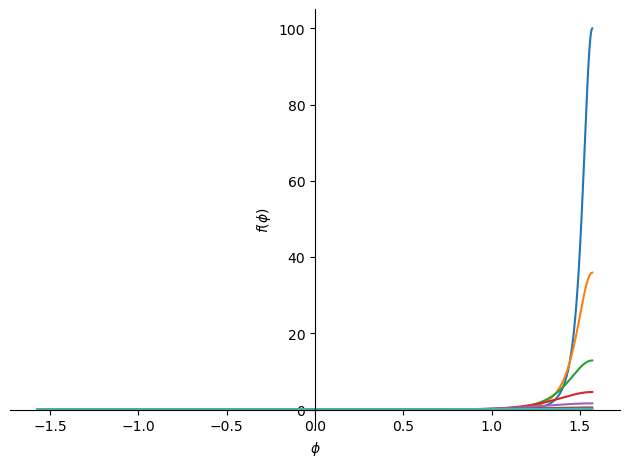

(z_s - sin(phi))*(z_s*sin(phi) + sqrt((z_s*sin(phi) - 1)**2) - 1)*sqrt(sin(phi)**2)/(2*(z_s**2 - 2*z_s*sin(phi) + 1)**2)

In [2]:
l = 0
m = 0
Plm = poly.assoc_legendre(l, m, sp.sin(phi))

integrand = cos_tilde_alpha_xy0_rru[2].subs({Re: 1}) * Plm * sp.cos(m*lam) * sp.sqrt((sp.sin(phi))**2)
all_expr = [integrand.subs({zsat: 1+f}) for f in np.logspace(-1, np.log10(10), 10)]

sp.plotting.plot(*all_expr, (phi, -sp.pi/2, sp.pi/2))
sp.simplify(integrand)


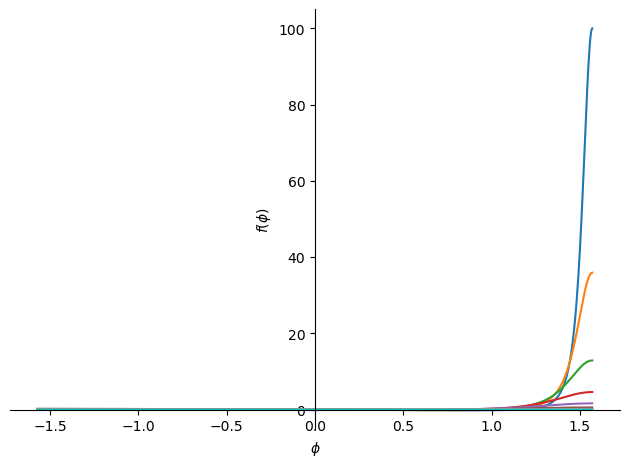

KeyboardInterrupt: 

In [5]:
l = 0
m = 0
Plm = poly.assoc_legendre(l, m, sp.sin(phi))
integrand_pos = cos_alpha_xy0_rru[2].subs({Re: 1}) * Plm * sp.cos(m*lam) * sp.sin(phi)
all_expr = [integrand_pos.subs({zsat: 1+f}) for f in np.logspace(-1, np.log10(10), 10)]

sp.plotting.plot(*all_expr, (phi, -sp.pi/2, sp.pi/2))
sp.simplify(sp.integrate(integrand_pos, (phi, sp.pi/2-sp.acos(1/zsat), sp.pi/2 )))

(z_s**4*(pi - 2*acos(1/z_s))*cot(acos(1/z_s)/2 + pi/4)**4 + 2*z_s**4*(pi - 2*acos(1/z_s))*cot(acos(1/z_s)/2 + pi/4)**2 + z_s**4*(pi - 2*acos(1/z_s)) - 2*I*z_s**4*log((I*z_s + (z_s - I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s - I))*cot(acos(1/z_s)/2 + pi/4)**4 - 4*I*z_s**4*log((I*z_s + (z_s - I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s - I))*cot(acos(1/z_s)/2 + pi/4)**2 - 2*I*z_s**4*log((I*z_s + (z_s - I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s - I)) + 2*I*z_s**4*log((-I*z_s + (z_s + I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s + I))*cot(acos(1/z_s)/2 + pi/4)**4 + 4*I*z_s**4*log((-I*z_s + (z_s + I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s + I))*cot(acos(1/z_s)/2 + pi/4)**2 + 2*I*z_s**4*log((-I*z_s + (z_s + I)*cot(acos(1/z_s)/2 + pi/4) - 1)/(z_s + I)) - 8*z_s**3*cot(acos(1/z_s)/2 + pi/4)**2 - 8*z_s**3 + 4*z_s**2*(2*acos(1/z_s) - pi)*cot(acos(1/z_s)/2 + pi/4)**4 + 8*z_s**2*(2*acos(1/z_s) - pi)*cot(acos(1/z_s)/2 + pi/4)**2 + 4*z_s**2*(2*acos(1/z_s) - pi) + z_s**2*(cot(acos(1/z_s)/2 + pi/4)**4 + 2*cot(acos(1/z_s)/

In [ ]:
cos_tilde_alpha = sp.simplify(cos_tilde_alpha.subs({xsat: R_sat*sp.cos(phi_sat)*sp.cos(lam_sat), 
                                                    ysat: R_sat*sp.cos(phi_sat)*sp.sin(lam_sat), 
                                                    zsat: R_sat*sp.sin(phi_sat)}))
#cos_tilde_alpha
sp.limit(cos_tilde_alpha, R_sat, sp.oo)

sqrt(sin(phi)**2*sin(phi_s)**2 + 2*sin(phi)*sin(phi_s)*cos(phi)*cos(phi_s)*cos(lambda - lambda_s) + cos(phi)**2*cos(phi_s)**2*cos(lambda - lambda_s)**2)/2 + sin(lambda)*sin(lambda_s)*cos(phi)*cos(phi_s)/2 + sin(phi)*sin(phi_s)/2 + cos(lambda)*cos(lambda_s)*cos(phi)*cos(phi_s)/2